<a href="https://colab.research.google.com/github/satyamshrivastav955-dotcom/argus-vlm-optimization/blob/main/edi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ================================================================
# CELL 1 — Environment setup (skip if already run this session)
# ================================================================
import sys, subprocess
import importlib.metadata as metadata

TARGET_TRANSFORMERS = "4.57.2"
try:
    current_transformers = metadata.version("transformers")
except Exception:
    current_transformers = None

if current_transformers != TARGET_TRANSFORMERS:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "--force-reinstall", "--no-deps", f"transformers=={TARGET_TRANSFORMERS}",
    ])
    print(f"Installed transformers {TARGET_TRANSFORMERS}. If first install, RESTART RUNTIME and rerun.")
else:
    print(f"Transformers {TARGET_TRANSFORMERS} already installed.")

try:
    import hqq  # noqa
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "hqq"])

import torch, numpy as np
if not torch.cuda.is_available():
    raise RuntimeError("CUDA GPU required.")
print("GPU:", torch.cuda.get_device_name(0))

Installed transformers 4.57.2. If first install, RESTART RUNTIME and rerun.
GPU: Tesla T4


In [2]:
# ================================================================
# CELL 2 — Load Qwen2.5-VL (skip if already run this session)
# ================================================================
from PIL import Image
import cv2
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration

MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"
DEVICE = "cuda"

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID, dtype=torch.float16, device_map=DEVICE,
)
model.eval()
vision_model = model.model.visual
print("Loaded:", MODEL_ID)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. Note that this behavior will be extended to all models in a future release.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

model-00001-of-00002.safetensors:   0%|          | 0.00/3.98G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/3.53G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Loaded: Qwen/Qwen2.5-VL-3B-Instruct


In [4]:
# ================================================================
# CELL 3 — Core functions (this defines extract_visual_features_with_premerge)
# ================================================================
PROMPT = (
    "Describe the image for a surveillance system. "
    "Identify people, vehicles, important objects, actions, "
    "and anything unusual. Be concise but preserve important visual information."
)

def prepare_qwen_inputs(image, prompt=PROMPT):
    messages = [{"role": "user", "content": [
        {"type": "image", "image": image}, {"type": "text", "text": prompt},
    ]}]
    chat_text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = processor(text=[chat_text], images=[image], return_tensors="pt")
    return inputs.to(DEVICE)

def extract_visual_features_with_premerge(image):
    inputs = prepare_qwen_inputs(image)
    captured = {}

    def capture_merger_input(module, module_inputs):
        captured["premerge"] = module_inputs[0].detach()

    def capture_merger_output(module, module_inputs, module_output):
        captured["merged_window_order"] = module_output.detach()

    pre_hook = vision_model.merger.register_forward_pre_hook(capture_merger_input)
    post_hook = vision_model.merger.register_forward_hook(capture_merger_output)
    try:
        with torch.no_grad():
            out = model.get_image_features(inputs["pixel_values"], inputs["image_grid_thw"])
    finally:
        pre_hook.remove(); post_hook.remove()

    if isinstance(out, (tuple, list)):
        if len(out) != 1:
            raise RuntimeError(f"Expected one image feature tensor, got {len(out)}.")
        merged_features = out[0].detach()
    elif torch.is_tensor(out):
        merged_features = out.detach()
    else:
        raise TypeError(f"Unexpected get_image_features() return type: {type(out)}")

    premerge_features = captured["premerge"]
    merged_window_order = captured["merged_window_order"]

    merge_unit = vision_model.spatial_merge_unit
    if premerge_features.shape[0] % merge_unit != 0:
        raise RuntimeError(f"Pre-merge patch count not divisible by merge unit={merge_unit}.")
    expected = premerge_features.shape[0] // merge_unit
    if merged_window_order.shape[0] != expected or merged_features.shape[0] != expected:
        raise RuntimeError("Merged token count mismatch vs expected.")

    return inputs, merged_features, premerge_features, merged_window_order

print("extract_visual_features_with_premerge defined.")

extract_visual_features_with_premerge defined.


In [5]:
# ================================================================
# CELL 4 — build_full_multimodal_package (no pruning path)
# ================================================================
def build_full_multimodal_package(inputs, merged_image_features):
    input_ids = inputs["input_ids"]
    full_position_ids, rope_delta = model.model.get_rope_index(
        input_ids, image_grid_thw=inputs["image_grid_thw"],
        attention_mask=inputs.get("attention_mask"),
    )
    attention_mask = inputs.get("attention_mask", torch.ones_like(input_ids))
    embeds = model.get_input_embeddings()(input_ids).to(dtype=model.dtype)
    image_positions = torch.where(input_ids[0] == model.config.image_token_id)[0]
    if image_positions.numel() != merged_image_features.shape[0]:
        raise RuntimeError("Image placeholders do not match visual features.")
    embeds[0, image_positions, :] = merged_image_features.to(device=embeds.device, dtype=embeds.dtype)
    return {"input_ids": input_ids, "inputs_embeds": embeds,
            "position_ids": full_position_ids, "attention_mask": attention_mask, "rope_delta": rope_delta}

print("build_full_multimodal_package defined.")

build_full_multimodal_package defined.


In [6]:
# ================================================================
# CELL 5 — custom_generate with configurable KV cache
# ================================================================
import gc, time
from transformers.cache_utils import DynamicCache, QuantizedCache

def make_cache(cfg):
    if cfg["kind"] == "dynamic":
        return DynamicCache(config=model.config)
    return QuantizedCache(
        backend="hqq", config=model.config, nbits=cfg["nbits"],
        axis_key=1, axis_value=1,
        q_group_size=cfg.get("q_group_size", 64), residual_length=cfg.get("residual_length", 32),
    )

def custom_generate(package, cfg=None, max_new_tokens=150, rep_penalty=1.3, no_repeat_ngram=3):
    if cfg is None:
        cfg = {"kind": "dynamic"}
    gc.collect(); torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    cache = make_cache(cfg)

    inputs_embeds = package["inputs_embeds"]
    position_ids = package["position_ids"]
    attention_mask = package["attention_mask"]
    prefix_length = inputs_embeds.shape[1]
    cache_position = torch.arange(prefix_length, device=inputs_embeds.device, dtype=torch.long)
    t0 = time.perf_counter()

    generated_ids_list = []
    seen_counts = {}

    def apply_penalties(logits):
        for tok, cnt in seen_counts.items():
            logits[0, tok] /= (rep_penalty ** min(cnt, 5))
        if len(generated_ids_list) >= no_repeat_ngram - 1:
            prefix = tuple(t.item() for t in generated_ids_list[-(no_repeat_ngram - 1):])
            for i in range(len(generated_ids_list) - no_repeat_ngram + 1):
                if tuple(t.item() for t in generated_ids_list[i:i + no_repeat_ngram - 1]) == prefix:
                    banned = generated_ids_list[i + no_repeat_ngram - 1].item()
                    logits[0, banned] = -float("inf")
        return logits

    with torch.no_grad():
        outputs = model.language_model(
            input_ids=None, inputs_embeds=inputs_embeds, position_ids=position_ids,
            attention_mask=attention_mask, past_key_values=cache, use_cache=True,
            cache_position=cache_position, return_dict=True,
        )
        logits = model.lm_head(outputs.last_hidden_state[:, -1, :])
        next_token = logits.argmax(dim=-1, keepdim=True)
        generated_ids_list.append(next_token[0])
        seen_counts[int(next_token.item())] = seen_counts.get(int(next_token.item()), 0) + 1
        generated = [next_token]

        eos_token_id = model.generation_config.eos_token_id
        eos_ids = [eos_token_id] if isinstance(eos_token_id, int) else (list(eos_token_id) if eos_token_id else [])

        for step in range(1, max_new_tokens):
            if eos_ids and int(next_token.item()) in eos_ids:
                break
            token_embeddings = model.get_input_embeddings()(next_token).to(dtype=model.dtype)
            attention_mask = torch.cat([attention_mask, torch.ones(
                (attention_mask.shape[0], 1), dtype=attention_mask.dtype, device=attention_mask.device)], dim=1)
            next_position = position_ids[:, :, -1:] + 1
            next_cache_position = torch.tensor([prefix_length + step], device=inputs_embeds.device, dtype=torch.long)
            outputs = model.language_model(
                input_ids=None, inputs_embeds=token_embeddings, position_ids=next_position,
                attention_mask=attention_mask, past_key_values=cache, use_cache=True,
                cache_position=next_cache_position, return_dict=True,
            )
            logits = model.lm_head(outputs.last_hidden_state[:, -1, :])
            logits = apply_penalties(logits)
            next_token = logits.argmax(dim=-1, keepdim=True)
            generated_ids_list.append(next_token[0])
            seen_counts[int(next_token.item())] = seen_counts.get(int(next_token.item()), 0) + 1
            generated.append(next_token)
            position_ids = torch.cat([position_ids, next_position], dim=2)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - t0
    generated_ids = torch.cat(generated, dim=1)
    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    text = processor.batch_decode(generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0]
    return {"text": text, "tokens": int(generated_ids.shape[1]), "latency_s": elapsed,
            "tokens_per_s": generated_ids.shape[1] / elapsed if elapsed > 0 else None,
            "peak_vram_gb": peak_vram}

print("custom_generate defined.")

custom_generate defined.


Upload an image:


Saving WIN_20250520_13_06_54_Pro.jpg to WIN_20250520_13_06_54_Pro.jpg


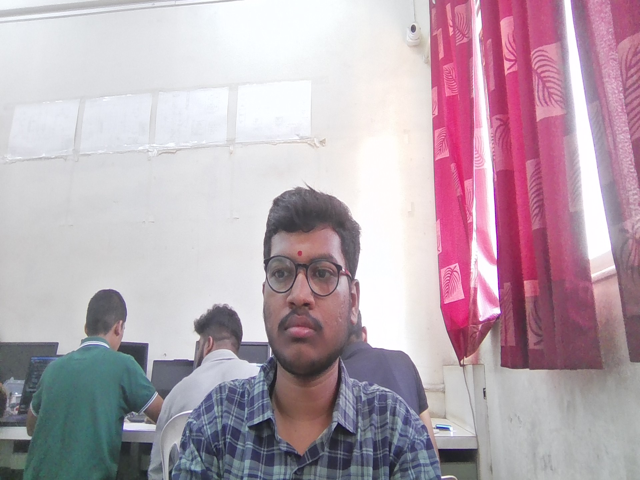

Visual tokens (unpruned): 391
Sequence length: 442 tokens

Config              Tokens  Latency(s)   tok/s  VRAM(GB)
------------------------------------------------------------
dynamic_fp16           150        9.00    16.7      7.60
hqq_int8_res32         150       10.88    13.8      7.60
hqq_int4_res32          21        1.84    11.4      7.59
hqq_int4_res64          21        2.13     9.9      7.59
hqq_int2_res32         103        9.64    10.7      7.59


--- dynamic_fp16 ---
**People:**
- A man in a green shirt is seated at the left side of an office desk.
- Another person, wearing glasses and with short hair, sits behind him on another chair.

**Important Objects/Actions:** 
1. **Computer Monitors**: There are multiple computer monitors visible around them; one directly to their right (the second individual) appears larger than others due its proximity or size difference between screens.
2. **Curtains/Coverings**: Red curtains hang from top-right corners covering windows that all

In [10]:
# ================================================================
# KV cache quantization comparison — NO pruning, full visual tokens
# Run Cells 1-5 first (env setup, model load, core functions,
# build_full_multimodal_package, custom_generate) before this.
# ================================================================
import torch
from google.colab import files
from PIL import Image

# ---------- 1. Upload one image ----------
print("Upload an image:")
uploaded = files.upload()
path = list(uploaded.keys())[0]

image = Image.open(path).convert("RGB").resize((640, 480))
display(image)

# ---------- 2. Extract visual features (full, no pruning) ----------
inputs, merged_features, premerge_features, _ = extract_visual_features_with_premerge(image)
print(f"Visual tokens (unpruned): {merged_features.shape[0]}")

# ---------- 3. Build the FULL (unpruned) multimodal package ----------
full_package = build_full_multimodal_package(inputs, merged_features)
print(f"Sequence length: {full_package['input_ids'].shape[1]} tokens\n")

# ---------- 4. Compare all KV cache configs on this full package ----------
MAX_NEW_TOKENS = 150

CACHE_CONFIGS = {
    "dynamic_fp16":   dict(kind="dynamic"),
    "hqq_int8_res32": dict(kind="hqq", nbits=8, residual_length=32, q_group_size=64),
    "hqq_int4_res32": dict(kind="hqq", nbits=4, residual_length=32, q_group_size=64),
    "hqq_int4_res64": dict(kind="hqq", nbits=4, residual_length=64, q_group_size=64),
    "hqq_int2_res32": dict(kind="hqq", nbits=2, residual_length=32, q_group_size=64),
}

print(f"{'Config':<18} {'Tokens':>7} {'Latency(s)':>11} {'tok/s':>7} {'VRAM(GB)':>9}")
print("-" * 60)
results = {}
for name, cfg in CACHE_CONFIGS.items():
    r = custom_generate(full_package, cfg, max_new_tokens=MAX_NEW_TOKENS)
    results[name] = r
    print(f"{name:<18} {r['tokens']:>7} {r['latency_s']:>11.2f} {r['tokens_per_s']:>7.1f} {r['peak_vram_gb']:>9.2f}")

print("\n" + "=" * 60)
for name, r in results.items():
    print(f"\n--- {name} ---")
    print(r["text"])

baseline_vram = results["dynamic_fp16"]["peak_vram_gb"]
print("\n" + "=" * 60)
print("VRAM saved vs fp16 baseline:")
for name, r in results.items():
    if name == "dynamic_fp16":
        continue
    saved = baseline_vram - r["peak_vram_gb"]
    print(f"  {name:<18}: {saved:+.3f} GB  ({100*saved/baseline_vram:+.1f}%)")

In [12]:
# ================================================================
# Long-video KV cache accumulation test
# Measures VRAM/latency for dynamic vs quantized cache as context
# grows across many real frames — this is the regime where cache
# quantization is actually supposed to help.
#
# Requires model/processor/vision_model already loaded (4-bit or fp16,
# either works — this isolates the CACHE question specifically) and
# extract_visual_features_with_premerge, build_full_multimodal_package
# already defined.
# ================================================================
import gc, time, torch
from google.colab import files
from transformers.cache_utils import DynamicCache, QuantizedCache

# ---------- 1. Upload a longer video ----------
print("Upload a video (longer = better for this test — aim for at least 20-30s).")
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]

FRAME_SAMPLE_EVERY_N = 10   # adjust based on video fps/length
MAX_FRAMES = 20             # each frame adds ~200-450 tokens; 20 frames ~ 4000-9000 tokens total

cap = cv2.VideoCapture(VIDEO_PATH)
frames = []
idx = 0
while cap.isOpened() and len(frames) < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    if idx % FRAME_SAMPLE_EVERY_N == 0:
        frame_resized = cv2.resize(frame, (640, 480))
        img = Image.fromarray(cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB))
        frames.append(img)
    idx += 1
cap.release()
print(f"Extracted {len(frames)} frames for accumulation test.\n")

if len(frames) < 5:
    raise RuntimeError("Need more frames for a meaningful long-context test — lower FRAME_SAMPLE_EVERY_N or use a longer video.")

# ---------- 2. Pre-extract visual features for all frames (one-time cost, not timed) ----------
print("Extracting visual features for all frames...")
frame_packages = []
for i, img in enumerate(frames):
    inputs, merged, _, _ = extract_visual_features_with_premerge(img)
    pkg = build_full_multimodal_package(inputs, merged)
    frame_packages.append(pkg)
    print(f"  Frame {i}: {pkg['input_ids'].shape[1]} tokens")

# ---------- 3. Accumulation run: feed frames one after another into a GROWING cache ----------
def make_cache(cache_type):
    if cache_type == "dynamic":
        return DynamicCache(config=model.config)
    if cache_type == "hqq_int8":
        return QuantizedCache(
            backend="hqq", config=model.config, nbits=8,
            axis_key=1, axis_value=1, q_group_size=64, residual_length=128,
        )
    if cache_type == "hqq_int4":
        return QuantizedCache(
            backend="hqq", config=model.config, nbits=4,
            axis_key=1, axis_value=1, q_group_size=64, residual_length=128,
        )
    raise ValueError(cache_type)

def run_accumulation(cache_type, frame_packages):
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    cache = make_cache(cache_type)

    total_tokens = 0
    position_offset = 0
    checkpoints = []  # (total_tokens_so_far, vram_gb, latency_this_step_s)

    for i, pkg in enumerate(frame_packages):
        embeds = pkg["inputs_embeds"]
        seq_len = embeds.shape[1]
        attention_mask = torch.ones((1, total_tokens + seq_len), dtype=torch.long, device=DEVICE)
        position_ids = pkg["position_ids"] + position_offset
        cache_position = torch.arange(total_tokens, total_tokens + seq_len, device=DEVICE, dtype=torch.long)

        t0 = time.perf_counter()
        with torch.no_grad():
            outputs = model.language_model(
                input_ids=None, inputs_embeds=embeds, position_ids=position_ids,
                attention_mask=attention_mask, past_key_values=cache, use_cache=True,
                cache_position=cache_position, return_dict=True,
            )
        torch.cuda.synchronize()
        step_latency = time.perf_counter() - t0

        total_tokens += seq_len
        position_offset += seq_len
        vram_now = torch.cuda.memory_allocated() / 1e9
        checkpoints.append((total_tokens, vram_now, step_latency))

    peak_vram = torch.cuda.max_memory_allocated() / 1e9
    return checkpoints, peak_vram

print("\nRunning accumulation with dynamic (fp16) cache...")
checkpoints_dynamic, peak_dynamic = run_accumulation("dynamic", frame_packages)

print("Running accumulation with HQQ INT8 cache...")
checkpoints_int8, peak_int8 = run_accumulation("hqq_int8", frame_packages)

print("Running accumulation with HQQ INT4 cache...")
checkpoints_int4, peak_int4 = run_accumulation("hqq_int4", frame_packages)

# ---------- 4. Report ----------
print("\n" + "=" * 80)
print(f"{'Frames':>7} {'Tokens':>8} {'Dyn VRAM':>10} {'INT8 VRAM':>10} {'INT4 VRAM':>10} {'INT8 saved':>11} {'INT4 saved':>11}")
for i in range(len(checkpoints_dynamic)):
    tok = checkpoints_dynamic[i][0]
    v_dyn = checkpoints_dynamic[i][1]
    v_i8 = checkpoints_int8[i][1]
    v_i4 = checkpoints_int4[i][1]
    print(f"{i+1:>7} {tok:>8} {v_dyn:>9.2f}G {v_i8:>9.2f}G {v_i4:>9.2f}G "
          f"{v_dyn - v_i8:>+10.3f}G {v_dyn - v_i4:>+10.3f}G")

print("\n" + "=" * 80)
print(f"Peak VRAM — dynamic: {peak_dynamic:.2f} GB | INT8: {peak_int8:.2f} GB | INT4: {peak_int4:.2f} GB")
print(f"Final context length: {checkpoints_dynamic[-1][0]} tokens")
print(f"Peak VRAM saved — INT8: {peak_dynamic - peak_int8:+.3f} GB | INT4: {peak_dynamic - peak_int4:+.3f} GB")

Upload a video (longer = better for this test — aim for at least 20-30s).


Saving WIN_20260923_19_28_50_Pro.mp4 to WIN_20260923_19_28_50_Pro.mp4
Extracted 20 frames for accumulation test.

Extracting visual features for all frames...
  Frame 0: 442 tokens
  Frame 1: 442 tokens
  Frame 2: 442 tokens
  Frame 3: 442 tokens
  Frame 4: 442 tokens
  Frame 5: 442 tokens
  Frame 6: 442 tokens
  Frame 7: 442 tokens
  Frame 8: 442 tokens
  Frame 9: 442 tokens
  Frame 10: 442 tokens
  Frame 11: 442 tokens
  Frame 12: 442 tokens
  Frame 13: 442 tokens
  Frame 14: 442 tokens
  Frame 15: 442 tokens
  Frame 16: 442 tokens
  Frame 17: 442 tokens
  Frame 18: 442 tokens
  Frame 19: 442 tokens

Running accumulation with dynamic (fp16) cache...
Running accumulation with HQQ INT8 cache...
Running accumulation with HQQ INT4 cache...

 Frames   Tokens   Dyn VRAM  INT8 VRAM  INT4 VRAM  INT8 saved  INT4 saved
      1      442      7.59G      7.59G      7.58G     +0.008G     +0.012G
      2      884      7.61G      7.60G      7.60G     +0.008G     +0.012G
      3     1326      7.63G  

In [13]:
# ================================================================
# Long-video KV cache accumulation — fixed frame coverage + real text output
# ================================================================
import gc, time, torch
from google.colab import files
from transformers.cache_utils import DynamicCache, QuantizedCache

print("Upload a video:")
uploaded = files.upload()
VIDEO_PATH = list(uploaded.keys())[0]

# ---------- 1. Sample frames proportionally across the WHOLE video ----------
MAX_FRAMES = 100 # raise this if you have VRAM headroom; each frame ~440 tokens

cap = cv2.VideoCapture(VIDEO_PATH)
total_video_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
fps = cap.get(cv2.CAP_PROP_FPS)
duration_s = total_video_frames / fps if fps > 0 else 0
print(f"Video: {total_video_frames} frames, {fps:.1f} fps, {duration_s:.1f}s duration")

# Evenly space MAX_FRAMES samples across the entire video, not just the start
sample_indices = set(
    int(i * total_video_frames / MAX_FRAMES) for i in range(MAX_FRAMES)
)

frames = []
idx = 0
while cap.isOpened() and len(frames) < MAX_FRAMES:
    ret, frame = cap.read()
    if not ret:
        break
    if idx in sample_indices:
        frame_resized = cv2.resize(frame, (640, 480))
        img = Image.fromarray(cv2.cvtColor(frame_resized, cv2.COLOR_BGR2RGB))
        frames.append(img)
    idx += 1
cap.release()
print(f"Extracted {len(frames)} frames spanning the full {duration_s:.1f}s video.\n")

# ---------- 2. Extract visual features for all frames ----------
print("Extracting visual features...")
frame_packages = []
for i, img in enumerate(frames):
    inputs, merged, _, _ = extract_visual_features_with_premerge(img)
    pkg = build_full_multimodal_package(inputs, merged)
    frame_packages.append(pkg)
print(f"Done. {len(frame_packages)} frames, {frame_packages[0]['input_ids'].shape[1]} tokens each.\n")

# ---------- 3. Accumulation + generation at the end, for each cache type ----------
def make_cache(cache_type):
    if cache_type == "dynamic":
        return DynamicCache(config=model.config)
    if cache_type == "hqq_int8":
        return QuantizedCache(backend="hqq", config=model.config, nbits=8,
                               axis_key=1, axis_value=1, q_group_size=64, residual_length=128)
    if cache_type == "hqq_int4":
        return QuantizedCache(backend="hqq", config=model.config, nbits=4,
                               axis_key=1, axis_value=1, q_group_size=64, residual_length=128)
    raise ValueError(cache_type)

def run_accumulation_and_generate(cache_type, frame_packages, max_new_tokens=120, rep_penalty=1.3):
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    cache = make_cache(cache_type)

    total_tokens = 0
    position_offset = 0
    checkpoints = []
    last_hidden = None

    # Prefill all frames into the growing cache
    for pkg in frame_packages:
        embeds = pkg["inputs_embeds"]
        seq_len = embeds.shape[1]
        attention_mask = torch.ones((1, total_tokens + seq_len), dtype=torch.long, device=DEVICE)
        position_ids = pkg["position_ids"] + position_offset
        cache_position = torch.arange(total_tokens, total_tokens + seq_len, device=DEVICE, dtype=torch.long)

        with torch.no_grad():
            outputs = model.language_model(
                input_ids=None, inputs_embeds=embeds, position_ids=position_ids,
                attention_mask=attention_mask, past_key_values=cache, use_cache=True,
                cache_position=cache_position, return_dict=True,
            )
        total_tokens += seq_len
        position_offset += seq_len
        checkpoints.append((total_tokens, torch.cuda.memory_allocated() / 1e9))
        last_hidden = outputs.last_hidden_state
        last_attention_mask = attention_mask
        last_position_ids = position_ids

    # ---- Now GENERATE text conditioned on the full accumulated context ----
    logits = model.lm_head(last_hidden[:, -1, :])
    next_token = logits.argmax(dim=-1, keepdim=True)
    generated = [next_token]
    seen_counts = {int(next_token.item()): 1}
    position_ids = last_position_ids
    attention_mask = last_attention_mask

    eos_token_id = model.generation_config.eos_token_id
    eos_ids = [eos_token_id] if isinstance(eos_token_id, int) else (list(eos_token_id) if eos_token_id else [])

    for step in range(1, max_new_tokens):
        if eos_ids and int(next_token.item()) in eos_ids:
            break
        token_embeddings = model.get_input_embeddings()(next_token).to(dtype=model.dtype)
        attention_mask = torch.cat([attention_mask, torch.ones((1, 1), dtype=attention_mask.dtype, device=DEVICE)], dim=1)
        next_position = position_ids[:, :, -1:] + 1
        next_cache_position = torch.tensor([total_tokens + step - 1], device=DEVICE, dtype=torch.long)
        with torch.no_grad():
            outputs = model.language_model(
                input_ids=None, inputs_embeds=token_embeddings, position_ids=next_position,
                attention_mask=attention_mask, past_key_values=cache, use_cache=True,
                cache_position=next_cache_position, return_dict=True,
            )
        logits = model.lm_head(outputs.last_hidden_state[:, -1, :])
        for tok, cnt in seen_counts.items():
            logits[0, tok] /= (rep_penalty ** min(cnt, 5))
        next_token = logits.argmax(dim=-1, keepdim=True)
        seen_counts[int(next_token.item())] = seen_counts.get(int(next_token.item()), 0) + 1
        generated.append(next_token)
        position_ids = torch.cat([position_ids, next_position], dim=2)

    torch.cuda.synchronize()
    generated_ids = torch.cat(generated, dim=1)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    peak_vram = torch.cuda.max_memory_allocated() / 1e9

    return checkpoints, peak_vram, text

PROMPT_SUFFIX_NOTE = "(Note: final generation is conditioned on ALL accumulated frames' visual context.)"

print("Running dynamic (fp16)...")
checkpoints_dynamic, peak_dynamic, text_dynamic = run_accumulation_and_generate("dynamic", frame_packages)

print("Running HQQ INT8...")
checkpoints_int8, peak_int8, text_int8 = run_accumulation_and_generate("hqq_int8", frame_packages)

print("Running HQQ INT4...")
checkpoints_int4, peak_int4, text_int4 = run_accumulation_and_generate("hqq_int4", frame_packages)

# ---------- 4. Report ----------
print("\n" + "=" * 80)
print(f"{'Frames':>7} {'Tokens':>8} {'Dyn VRAM':>10} {'INT8 VRAM':>10} {'INT4 VRAM':>10} {'INT8 saved':>11} {'INT4 saved':>11}")
for i in range(len(checkpoints_dynamic)):
    tok = checkpoints_dynamic[i][0]
    v_dyn, v_i8, v_i4 = checkpoints_dynamic[i][1], checkpoints_int8[i][1], checkpoints_int4[i][1]
    print(f"{i+1:>7} {tok:>8} {v_dyn:>9.2f}G {v_i8:>9.2f}G {v_i4:>9.2f}G {v_dyn-v_i8:>+10.3f}G {v_dyn-v_i4:>+10.3f}G")

print("\n" + "=" * 80)
print(f"Peak VRAM — dynamic: {peak_dynamic:.2f}GB | INT8: {peak_int8:.2f}GB | INT4: {peak_int4:.2f}GB")
print(f"Final context: {checkpoints_dynamic[-1][0]} tokens across {len(frames)} frames spanning {duration_s:.1f}s of video")
print(f"Peak VRAM saved — INT8: {peak_dynamic-peak_int8:+.3f}GB | INT4: {peak_dynamic-peak_int4:+.3f}GB")

print("\n" + "=" * 80)
print("GENERATED TEXT (conditioned on full accumulated video context):\n")
print("--- dynamic_fp16 ---")
print(text_dynamic)
print("\n--- hqq_int8 ---")
print(text_int8)
print("\n--- hqq_int4 ---")
print(text_int4)

Upload a video:


Saving WIN_20260923_19_28_50_Pro.mp4 to WIN_20260923_19_28_50_Pro (1).mp4
Video: 617 frames, 19.9 fps, 31.1s duration
Extracted 100 frames spanning the full 31.1s video.

Extracting visual features...
Done. 100 frames, 442 tokens each.

Running dynamic (fp16)...
Running HQQ INT8...
Running HQQ INT4...

 Frames   Tokens   Dyn VRAM  INT8 VRAM  INT4 VRAM  INT8 saved  INT4 saved
      1      442      7.74G      7.74G      7.73G     +0.008G     +0.012G
      2      884      7.76G      7.76G      7.75G     +0.008G     +0.012G
      3     1326      7.78G      7.76G      7.74G     +0.023G     +0.035G
      4     1768      7.80G      7.77G      7.76G     +0.023G     +0.035G
      5     2210      7.85G      7.77G      7.75G     +0.081G     +0.101G
      6     2652      7.86G      7.79G      7.77G     +0.068G     +0.088G
      7     3094      7.86G      7.79G      7.76G     +0.069G     +0.097G
      8     3536      7.86G      7.81G      7.78G     +0.055G     +0.083G
      9     3978      7.89G   

In [ ]:
# ================================================================
# Pruning functions — required before running temporal pruning
# ================================================================
import torch.nn.functional as F
import math

def build_temporal_pruning_mask(previous_premerge, current_premerge, threshold=0.98):
    if previous_premerge.shape != current_premerge.shape:
        raise ValueError(
            f"Feature shapes do not match: {previous_premerge.shape} vs {current_premerge.shape}."
        )
    sim = F.cosine_similarity(previous_premerge.float(), current_premerge.float(), dim=-1)
    merge_unit = vision_model.spatial_merge_unit
    grouped_similarity = sim.view(-1, merge_unit)
    keep_window_order = (grouped_similarity < threshold).any(dim=1)
    window_index, _ = vision_model.get_window_index(inputs_b_grid_thw)
    reverse_indices = torch.argsort(window_index)
    keep_original_order = keep_window_order[reverse_indices]
    return keep_original_order, sim, grouped_similarity, reverse_indices

def enforce_minimum_keep_ratio(keep_mask, similarity_per_merged_token, min_keep_ratio=0.05):
    total = keep_mask.numel()
    min_keep = max(1, math.ceil(total * min_keep_ratio))
    if int(keep_mask.sum()) >= min_keep:
        return keep_mask
    _, indices = torch.topk(similarity_per_merged_token, k=min_keep, largest=False)
    safe_mask = torch.zeros_like(keep_mask, dtype=torch.bool)
    safe_mask[indices] = True
    return safe_mask

def build_pruned_multimodal_package(inputs, merged_image_features, keep_mask):
    original_input_ids = inputs["input_ids"]
    image_token_id = model.config.image_token_id
    image_positions = torch.where(original_input_ids[0] == image_token_id)[0]

    if image_positions.numel() != merged_image_features.shape[0]:
        raise RuntimeError("Image token count != visual feature count.")
    if keep_mask.numel() != merged_image_features.shape[0]:
        raise RuntimeError("Keep-mask length != visual feature count.")

    sequence_keep_mask = torch.ones(original_input_ids.shape[1], dtype=torch.bool, device=original_input_ids.device)
    sequence_keep_mask[image_positions[~keep_mask]] = False

    pruned_input_ids = original_input_ids[:, sequence_keep_mask]

    full_position_ids, rope_delta = model.model.get_rope_index(
        original_input_ids, image_grid_thw=inputs["image_grid_thw"],
        attention_mask=inputs.get("attention_mask"),
    )
    pruned_position_ids = full_position_ids[:, :, sequence_keep_mask]

    original_attention_mask = inputs.get("attention_mask", torch.ones_like(original_input_ids))
    pruned_attention_mask = original_attention_mask[:, sequence_keep_mask]

    pruned_embeds = model.get_input_embeddings()(pruned_input_ids).to(dtype=model.dtype)
    remaining_image_positions = torch.where(pruned_input_ids[0] == image_token_id)[0]
    selected_visual_features = merged_image_features[keep_mask].to(
        device=pruned_embeds.device, dtype=pruned_embeds.dtype)

    if remaining_image_positions.numel() != selected_visual_features.shape[0]:
        raise RuntimeError("Remaining placeholders != selected visual features.")

    pruned_embeds[0, remaining_image_positions, :] = selected_visual_features

    return {
        "input_ids": pruned_input_ids, "inputs_embeds": pruned_embeds,
        "position_ids": pruned_position_ids, "attention_mask": pruned_attention_mask,
        "rope_delta": rope_delta,
        "original_length": original_input_ids.shape[1],
        "pruned_length": pruned_input_ids.shape[1],
        "visual_tokens_before": merged_image_features.shape[0],
        "visual_tokens_after": int(keep_mask.sum()),
    }

print("Pruning functions defined: build_temporal_pruning_mask, enforce_minimum_keep_ratio, build_pruned_multimodal_package")

Pruning functions defined: build_temporal_pruning_mask, enforce_minimum_keep_ratio, build_pruned_multimodal_package


In [ ]:
# ================================================================
# Temporal pruning + KV cache accumulation, on the same long video
# Compares: unpruned (baseline), pruned+dynamic, pruned+INT8
# Requires: model, processor, vision_model, extract_visual_features_with_premerge,
#           build_temporal_pruning_mask, enforce_minimum_keep_ratio,
#           build_pruned_multimodal_package, build_full_multimodal_package
#           (Cells 1-5 + pruning cells from earlier) already defined.
# Reuses the SAME video file already uploaded — no re-upload needed
# if VIDEO_PATH is still set from the last cell.
# ================================================================
import gc, time, torch
from transformers.cache_utils import DynamicCache, QuantizedCache

# ---------- 1. Re-sample frames the same way as before (skip if `frames` still in memory) ----------
if "frames" not in globals() or len(frames) == 0:
    raise NameError("frames not found — rerun the video sampling step from the previous cell first.")

print(f"Using {len(frames)} already-extracted frames.\n")

# ---------- 2. Apply temporal pruning ACROSS the whole sequence ----------
# Prune each frame against the PREVIOUS frame in the sampled sequence —
# this is the realistic Argus scenario: consecutive frames in the hot window.
PRUNE_THRESHOLD = 0.98
MIN_KEEP_RATIO = 0.05

print("Extracting features + building pruned packages for all frames...")
frame_packages_pruned = []
frame_packages_full = []
prev_premerge = None

pruning_stats = []

for i, img in enumerate(frames):
    inputs, merged, premerge, _ = extract_visual_features_with_premerge(img)
    full_pkg = build_full_multimodal_package(inputs, merged)
    frame_packages_full.append(full_pkg)

    if i == 0:
        # First frame: no previous frame to prune against, keep everything
        frame_packages_pruned.append(full_pkg)
        pruning_stats.append((merged.shape[0], merged.shape[0]))
        prev_premerge = premerge
        continue

    if prev_premerge.shape != premerge.shape:
        # Shape mismatch (rare, e.g. different grid) — fall back to unpruned for this frame
        frame_packages_pruned.append(full_pkg)
        pruning_stats.append((merged.shape[0], merged.shape[0]))
        prev_premerge = premerge
        continue

    inputs_b_grid_thw = inputs["image_grid_thw"]  # global needed by build_temporal_pruning_mask

    keep_mask, _, grouped_sim, reverse_idx = build_temporal_pruning_mask(
        prev_premerge, premerge, threshold=PRUNE_THRESHOLD
    )
    merged_sim = grouped_sim.mean(dim=1)[reverse_idx]
    keep_mask = enforce_minimum_keep_ratio(keep_mask, merged_sim, min_keep_ratio=MIN_KEEP_RATIO)

    tokens_before = merged.shape[0]
    tokens_after = int(keep_mask.sum())
    pruning_stats.append((tokens_before, tokens_after))

    pruned_pkg = build_pruned_multimodal_package(inputs, merged, keep_mask)
    frame_packages_pruned.append(pruned_pkg)

    prev_premerge = premerge

total_before = sum(s[0] for s in pruning_stats)
total_after = sum(s[1] for s in pruning_stats)
print(f"Total visual tokens: {total_before} -> {total_after} "
      f"({100*(1-total_after/total_before):.1f}% reduction across {len(frames)} frames)\n")

# ---------- 3. Accumulation + generation, reusing the same run function ----------
def make_cache(cache_type):
    if cache_type == "dynamic":
        return DynamicCache(config=model.config)
    if cache_type == "hqq_int8":
        return QuantizedCache(backend="hqq", config=model.config, nbits=8,
                               axis_key=1, axis_value=1, q_group_size=64, residual_length=128)
    raise ValueError(cache_type)

def run_accumulation_and_generate(cache_type, frame_packages, max_new_tokens=120, rep_penalty=1.3):
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats(); torch.cuda.synchronize()
    cache = make_cache(cache_type)

    total_tokens = 0
    position_offset = 0
    checkpoints = []
    last_hidden = None
    t_prefill0 = time.perf_counter()

    for pkg in frame_packages:
        # Handle both key names: build_full_multimodal_package uses "input_ids",
        # build_pruned_multimodal_package also has "input_ids" — both fine here.
        embeds = pkg["inputs_embeds"]
        seq_len = embeds.shape[1]
        attention_mask = torch.ones((1, total_tokens + seq_len), dtype=torch.long, device=DEVICE)
        position_ids = pkg["position_ids"] + position_offset
        cache_position = torch.arange(total_tokens, total_tokens + seq_len, device=DEVICE, dtype=torch.long)

        with torch.no_grad():
            outputs = model.language_model(
                input_ids=None, inputs_embeds=embeds, position_ids=position_ids,
                attention_mask=attention_mask, past_key_values=cache, use_cache=True,
                cache_position=cache_position, return_dict=True,
            )
        total_tokens += seq_len
        position_offset += seq_len
        checkpoints.append((total_tokens, torch.cuda.memory_allocated() / 1e9))
        last_hidden = outputs.last_hidden_state
        last_attention_mask = attention_mask
        last_position_ids = position_ids

    torch.cuda.synchronize()
    prefill_time = time.perf_counter() - t_prefill0

    # Generate conditioned on full accumulated context
    logits = model.lm_head(last_hidden[:, -1, :])
    next_token = logits.argmax(dim=-1, keepdim=True)
    generated = [next_token]
    seen_counts = {int(next_token.item()): 1}
    position_ids = last_position_ids
    attention_mask = last_attention_mask

    eos_token_id = model.generation_config.eos_token_id
    eos_ids = [eos_token_id] if isinstance(eos_token_id, int) else (list(eos_token_id) if eos_token_id else [])

    for step in range(1, max_new_tokens):
        if eos_ids and int(next_token.item()) in eos_ids:
            break
        token_embeddings = model.get_input_embeddings()(next_token).to(dtype=model.dtype)
        attention_mask = torch.cat([attention_mask, torch.ones((1, 1), dtype=attention_mask.dtype, device=DEVICE)], dim=1)
        next_position = position_ids[:, :, -1:] + 1
        next_cache_position = torch.tensor([total_tokens + step - 1], device=DEVICE, dtype=torch.long)
        with torch.no_grad():
            outputs = model.language_model(
                input_ids=None, inputs_embeds=token_embeddings, position_ids=next_position,
                attention_mask=attention_mask, past_key_values=cache, use_cache=True,
                cache_position=next_cache_position, return_dict=True,
            )
        logits = model.lm_head(outputs.last_hidden_state[:, -1, :])
        for tok, cnt in seen_counts.items():
            logits[0, tok] /= (rep_penalty ** min(cnt, 5))
        next_token = logits.argmax(dim=-1, keepdim=True)
        seen_counts[int(next_token.item())] = seen_counts.get(int(next_token.item()), 0) + 1
        generated.append(next_token)
        position_ids = torch.cat([position_ids, next_position], dim=2)

    generated_ids = torch.cat(generated, dim=1)
    text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
    peak_vram = torch.cuda.max_memory_allocated() / 1e9

    return checkpoints, peak_vram, text, prefill_time

print("Running UNPRUNED baseline (dynamic fp16)...")
cp_full_dyn, peak_full_dyn, text_full_dyn, t_full_dyn = run_accumulation_and_generate("dynamic", frame_packages_full)

print("Running PRUNED + dynamic (fp16)...")
cp_pruned_dyn, peak_pruned_dyn, text_pruned_dyn, t_pruned_dyn = run_accumulation_and_generate("dynamic", frame_packages_pruned)

print("Running PRUNED + INT8...")
cp_pruned_int8, peak_pruned_int8, text_pruned_int8, t_pruned_int8 = run_accumulation_and_generate("hqq_int8", frame_packages_pruned)

# ---------- 4. Report ----------
print("\n" + "=" * 80)
print(f"{'Config':<25} {'Final tokens':>13} {'Peak VRAM':>10} {'Prefill(s)':>11}")
print(f"{'unpruned + dynamic':<25} {cp_full_dyn[-1][0]:>13} {peak_full_dyn:>9.2f}G {t_full_dyn:>10.2f}s")
print(f"{'pruned + dynamic':<25} {cp_pruned_dyn[-1][0]:>13} {peak_pruned_dyn:>9.2f}G {t_pruned_dyn:>10.2f}s")
print(f"{'pruned + INT8':<25} {cp_pruned_int8[-1][0]:>13} {peak_pruned_int8:>9.2f}G {t_pruned_int8:>10.2f}s")

print("\n" + "=" * 80)
print("Combined savings vs unpruned+dynamic baseline:")
print(f"  Token reduction (pruning alone): {100*(1 - cp_pruned_dyn[-1][0]/cp_full_dyn[-1][0]):.1f}%")
print(f"  VRAM saved (pruned+dynamic):     {peak_full_dyn - peak_pruned_dyn:+.3f} GB")
print(f"  VRAM saved (pruned+INT8):        {peak_full_dyn - peak_pruned_int8:+.3f} GB "
      f"({100*(peak_full_dyn - peak_pruned_int8)/peak_full_dyn:.1f}% of baseline)")
print(f"  Prefill speedup (pruned+dynamic vs unpruned): {t_full_dyn/t_pruned_dyn:.2f}x")
print(f"  Prefill speedup (pruned+INT8 vs unpruned):    {t_full_dyn/t_pruned_int8:.2f}x")

print("\n" + "=" * 80)
print("GENERATED TEXT:\n")
print("--- unpruned + dynamic ---")
print(text_full_dyn)
print("\n--- pruned + dynamic ---")
print(text_pruned_dyn)
print("\n--- pruned + INT8 ---")
print(text_pruned_int8)

Using 100 already-extracted frames.

Extracting features + building pruned packages for all frames...
Total visual tokens: 39100 -> 23505 (39.9% reduction across 100 frames)

Running UNPRUNED baseline (dynamic fp16)...
Running PRUNED + dynamic (fp16)...
Running PRUNED + INT8...

Config                     Final tokens  Peak VRAM  Prefill(s)
unpruned + dynamic                44200     10.91G      60.43s
pruned + dynamic                  28605      9.91G      33.14s
pruned + INT8                     28605      9.45G      78.06s

Combined savings vs unpruned+dynamic baseline:
  Token reduction (pruning alone): 35.3%
  VRAM saved (pruned+dynamic):     +0.997 GB
  VRAM saved (pruned+INT8):        +1.459 GB (13.4% of baseline)
  Prefill speedup (pruned+dynamic vs unpruned): 1.82x
  Prefill speedup (pruned+INT8 vs unpruned):    0.77x

GENERATED TEXT:

--- unpruned + dynamic ---
The image shows a section of an outdoor wall with some greenery in the background. The wall appears to be made of co

In [4]:
# ============================================================
# ARGUS - COLAB API SERVER
# One-cell setup: Install + FastAPI + Cloudflare Tunnel
# ============================================================

# -------------------------------
# 1. INSTALL REQUIRED PACKAGES
# -------------------------------
!pip -q install fastapi uvicorn python-multipart nest-asyncio

# Install Cloudflare Tunnel
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64.deb
!dpkg -i cloudflared-linux-amd64.deb >/dev/null 2>&1


# -------------------------------
# 2. IMPORTS
# -------------------------------
import torch
import uvicorn
import nest_asyncio
import threading
import subprocess
import time
import requests

from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware

nest_asyncio.apply()


# -------------------------------
# 3. CHECK GPU
# -------------------------------
print("========================================")
print("ARGUS COLAB BACKEND")
print("========================================")

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: CUDA GPU not detected")


# -------------------------------
# 4. CREATE FASTAPI APP
# -------------------------------
app = FastAPI(title="Argus VLM Optimization API")


# Allow your frontend to connect
app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_credentials=True,
    allow_methods=["*"],
    allow_headers=["*"],
)


# -------------------------------
# 5. HEALTH ENDPOINT
# -------------------------------
@app.get("/")
def home():
    return {
        "status": "running",
        "message": "Argus VLM Optimization API is running"
    }


@app.get("/health")
def health():

    gpu = (
        torch.cuda.get_device_name(0)
        if torch.cuda.is_available()
        else "No GPU"
    )

    return {
        "status": "healthy",
        "gpu": gpu
    }


# -------------------------------
# 6. START FASTAPI
# -------------------------------
def start_api():

    uvicorn.run(
        app,
        host="0.0.0.0",
        port=8000
    )


api_thread = threading.Thread(
    target=start_api,
    daemon=True
)

api_thread.start()

time.sleep(3)

print()
print("FastAPI server started.")
print("Local API: http://127.0.0.1:8000")


# -------------------------------
# 7. TEST LOCAL API
# -------------------------------
try:

    r = requests.get(
        "http://127.0.0.1:8000/health"
    )

    print()
    print("Local health check:")
    print(r.status_code)
    print(r.json())

except Exception as e:

    print("Local API test failed:")
    print(e)


# -------------------------------
# 8. START CLOUDFLARE TUNNEL
# -------------------------------
print()
print("Starting Cloudflare tunnel...")
print("WAIT FOR THE HTTPS URL BELOW.")
print()


process = subprocess.Popen(
    [
        "cloudflared",
        "tunnel",
        "--url",
        "http://127.0.0.1:8000"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1
)


public_url = None

start_time = time.time()

while time.time() - start_time < 30:

    line = process.stdout.readline()

    if not line:
        time.sleep(0.2)
        continue

    print(line.strip())

    if "trycloudflare.com" in line:

        parts = line.split()

        for part in parts:

            if "https://" in part and "trycloudflare.com" in part:

                public_url = part.strip()

                break

    if public_url:
        break


# -------------------------------
# 9. FINAL RESULT
# -------------------------------
print()
print("========================================")

if public_url:

    print("ARGUS PUBLIC API URL:")
    print(public_url)

    print()
    print("HEALTH URL:")
    print(public_url + "/health")

    print()
    print("Use this URL in your frontend.")

else:

    print("Could not automatically detect Cloudflare URL.")
    print("Check the Cloudflare output above.")

print("========================================")


from fastapi import UploadFile, File
from PIL import Image
import io

@app.post("/predict")
async def predict(image: UploadFile = File(...)):

    image_bytes = await image.read()
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")

    # Use your already-loaded Qwen model + processor here
    inputs = prepare_qwen_inputs(img, PROMPT)

    visual_features = extract_visual_features_with_premerge(img)

    package = build_full_multimodal_package(
        inputs,
        visual_features["merged_image_features"]
    )

    result = custom_generate(
        package,
        cfg=None,
        max_new_tokens=150
    )

    return {
        "filename": image.filename,
        "description": result
    }

ARGUS COLAB BACKEND
CUDA available: True
GPU: Tesla T4


INFO:     Started server process [10558]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 98] error while attempting to bind on address ('0.0.0.0', 8000): address already in use
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.



FastAPI server started.
Local API: http://127.0.0.1:8000
INFO:     127.0.0.1:45128 - "GET /health HTTP/1.1" 200 OK

Local health check:
200
{'status': 'healthy', 'gpu': 'Tesla T4'}

Starting Cloudflare tunnel...
WAIT FOR THE HTTPS URL BELOW.

2026-09-23T19:24:27Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-23T19:24:27Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-23T19:24:32Z INF +---------------------------------------------------

In [5]:
import threading
import uvicorn

def run_server():
    uvicorn.run(app, host="0.0.0.0", port=8000)

server_thread = threading.Thread(target=run_server, daemon=True)
server_thread.start()

INFO:     Started server process [10558]
INFO:     Waiting for application startup.
INFO:     Application startup complete.


In [6]:
import requests

url = "https://motivated-avenue-again-indexes.trycloudflare.com/health"

response = requests.get(url)

print(response.status_code)
print(response.json())

530


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [ ]:
!cloudflared tunnel --url http://127.0.0.1:8000

2026-09-23T19:27:01Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-09-23T19:27:01Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-09-23T19:27:06Z INF +--------------------------------------------------------------------------------------------+
2026-09-23T19:27:06Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-09-23T19:27:06Z INF |  https://knowledgestorm-even-belongs-computing.tryclou

ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/applications.py", line 96, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/middleware/errors.py", line 186, i

INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "POST /predict HTTP/1.1" 500 Internal Server Error


ERROR:    Exception in ASGI application
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/protocols/http/httptools_impl.py", line 422, in run_asgi
    result = await app(  # type: ignore[func-returns-value]
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
        self.scope, self.receive, self.send
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/usr/local/lib/python3.13/dist-packages/uvicorn/middleware/proxy_headers.py", line 63, in __call__
    return await self.app(scope, receive, send)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/fastapi/applications.py", line 1163, in __call__
    await super().__call__(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/applications.py", line 96, in __call__
    await self.middleware_stack(scope, receive, send)
  File "/usr/local/lib/python3.13/dist-packages/starlette/middleware/errors.py", line 186, i

INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET /health HTTP/1.1" 200 OK
INFO:     210.16.95.54:0 - "GET

In [ ]:
import requests

url = "https://knowledgestorm-even-belongs-computing.trycloudflare.com/predict"

r = requests.post(url)

print("Status:", r.status_code)
print("Response:", r.text)

In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
!fuser -k 8000/tcp